In [165]:
class MultipleLinearRegression:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        # ensure X and y are numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        # Add an offset / bias term (column of 1s) to X
        X = np.insert(X, 0, 1, axis=1)
        
        # Formula Betas: (X.T @ X)^-1 @ X.T @ y
        X_transpose = X.T
        XTX = X_transpose @ X
        XTy = X_transpose @ y
        Betas = np.linalg.inv(XTX) @ XTy
        
        self.intercept_ = Betas[0] # first values is the intercepts
        self.coef_ = Betas[1:] # remaining values are coefficients
    
    def predict(self, X):
        # ensure X is an numpy array
        X = np.array(X)
        
        # formula: y_pred = (X * coefficeints) + y_intercept
        return (X @ self.coef_) + self.intercept_
    
    def score(self, X, y):
        # ensure X and y are numpy arrays
        X = np.array(X)
        y = np.array(y)

        # predictions
        y_pred = self.predict(X) # pass X_test to predict
        
        # R2 score formula: 1 - (Residual / Total)
        total = np.sum((y - np.mean(y)) ** 2)
        residual = np.sum((y - y_pred) ** 2)
        return 1 - (residual / total)

In [166]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action='ignore')

In [167]:
X, y = load_diabetes(return_X_y=True)

In [168]:
X.shape

(442, 10)

In [169]:
y.shape

(442,)

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [171]:
X_train.shape

(353, 10)

In [172]:
X_test.shape

(89, 10)

In [173]:
y_test.shape

(89,)

In [174]:
model = MultipleLinearRegression()

In [175]:
model.fit(X_train, y_train)

In [176]:
y_pred = model.predict(X_test)

In [177]:
model.score(X_test, y_test)

0.4399338661568969

In [178]:
df = pd.read_csv('heart.csv')

In [179]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [180]:
df.shape

(1025, 14)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [182]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [183]:
X = df.iloc[:,:-1]

In [184]:
X.shape

(1025, 13)

In [185]:
y = df.iloc[:,-1:]

In [186]:
y.shape

(1025, 1)

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [188]:
X_train.shape

(820, 13)

In [189]:
LR = MultipleLinearRegression()

In [190]:
LR.fit(X_train, y_train)

In [191]:
LR.predict(X_test)

array([[-8.29555572e-02],
       [ 6.20192516e-01],
       [-1.22164568e-01],
       [-8.29555572e-02],
       [ 9.03087571e-01],
       [ 6.95915955e-01],
       [ 8.27102224e-02],
       [ 2.85803961e-02],
       [ 2.41999088e-01],
       [ 8.28805673e-01],
       [ 8.03205192e-01],
       [ 3.48363917e-01],
       [ 5.50434232e-01],
       [ 6.31408667e-01],
       [ 9.68789664e-01],
       [ 6.03280677e-01],
       [ 7.30607851e-01],
       [ 3.20334634e-01],
       [ 1.12212267e+00],
       [ 7.11349416e-01],
       [ 7.14100332e-01],
       [ 1.09677019e+00],
       [ 9.35186711e-01],
       [ 9.95326279e-02],
       [ 2.30420069e-01],
       [ 5.89209892e-01],
       [ 2.01330200e-01],
       [ 6.11978786e-01],
       [-1.88764055e-01],
       [ 5.67431733e-01],
       [-6.70341359e-02],
       [ 4.07550910e-01],
       [ 6.08720915e-01],
       [ 9.52760482e-02],
       [ 3.94790258e-01],
       [ 1.21652738e+00],
       [ 6.95788127e-01],
       [ 7.67886874e-01],
       [ 6.3

In [198]:
LR.score(X_test, y_test)

0.5176284099262582

In [219]:
df2 = pd.read_csv('Student_Performance.csv')

In [220]:
df2.shape

(10000, 6)

In [221]:
df2 = df2.drop(columns=['Extracurricular Activities'])

In [225]:
df2.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [222]:
df2.shape

(10000, 5)

In [223]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  int64  
 4   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 390.8 KB


In [224]:
df2.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [243]:
X = df2.iloc[:,:-1]

In [244]:
X

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,7,99,9,1
1,4,82,4,2
2,8,51,7,2
3,5,52,5,2
4,7,75,8,5
...,...,...,...,...
9995,1,49,4,2
9996,7,64,8,5
9997,6,83,8,5
9998,9,97,7,0


In [245]:
y = df2.iloc[:,-1:]

In [246]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [252]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [253]:
LR.fit(X_train, y_train)

In [254]:
LR.predict(X_test)

array([[27.78475827],
       [35.67275855],
       [80.13704055],
       ...,
       [45.30386959],
       [30.01163097],
       [68.34774703]])

In [255]:
LR.score(X_test, y_test)

0.9887873065706714

In [256]:
df3 = pd.read_csv('synthetic_package_data.csv')

In [257]:
df3.head()

,Age,IQ,CGPA,Years_of_Experience,Package_LPA
0,59,128,9.53,0,16.72
1,49,103,6.08,0,11.47
2,35,105,9.48,12,39.72
3,28,134,7.77,1,15.34
4,41,86,5.91,14,38.51


In [259]:
df3.shape

(50000, 5)

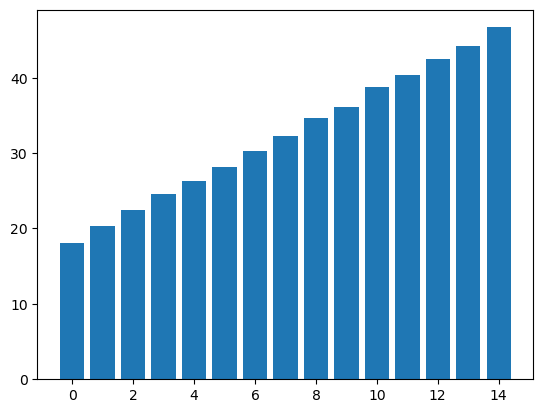

In [261]:
plt.bar(df3['Years_of_Experience'], df3['Package_LPA'])
plt.show()

In [263]:
X = df3.iloc[:,:-1]

In [264]:
X

,Age,IQ,CGPA,Years_of_Experience
0,59,128,9.53,0
1,49,103,6.08,0
2,35,105,9.48,12
3,28,134,7.77,1
4,41,86,5.91,14
...,...,...,...,...
49995,44,92,9.05,6
49996,40,115,8.03,5
49997,57,148,5.32,12
49998,51,154,6.94,13


In [265]:
y = df3.iloc[:,-1:]

In [266]:
y

,Package_LPA
0,16.72
1,11.47
2,39.72
3,15.34
4,38.51
...,...
49995,28.01
49996,23.59
49997,34.43
49998,38.85


In [267]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [271]:
X_test.shape

(10000, 4)

In [269]:
LR = MultipleLinearRegression()

In [278]:
LR.fit(X_train, y_train)

In [279]:
LR.predict(X_test)

array([[33.41906651],
       [19.53267101],
       [20.81796215],
       ...,
       [28.63971985],
       [31.92523976],
       [24.38300304]])

In [281]:
LR.score(X_test, y_test)

0.9968984383021282